In [1]:
import pandas as pd
import numpy as np
import random

df = pd.read_csv("/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv")
df


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [2]:
X = df.drop("country", axis=1).values #axis = 1 → columns
X
# .values -> converts df to numpy array 

array([[9.02e+01, 1.00e+01, 7.58e+00, ..., 5.62e+01, 5.82e+00, 5.53e+02],
       [1.66e+01, 2.80e+01, 6.55e+00, ..., 7.63e+01, 1.65e+00, 4.09e+03],
       [2.73e+01, 3.84e+01, 4.17e+00, ..., 7.65e+01, 2.89e+00, 4.46e+03],
       ...,
       [2.33e+01, 7.20e+01, 6.84e+00, ..., 7.31e+01, 1.95e+00, 1.31e+03],
       [5.63e+01, 3.00e+01, 5.18e+00, ..., 6.75e+01, 4.67e+00, 1.31e+03],
       [8.31e+01, 3.70e+01, 5.89e+00, ..., 5.20e+01, 5.40e+00, 1.46e+03]])

In [3]:
X.shape

(167, 9)

# eigenvalue decomposition

*A2 = A2 - eigval * np.outer(v, v)*

- Take the current matrix and remove the component explained by this eigenvector
- *suppose -> v = [v1, v2, v3]*

- outer(v, v) =
- 
[ v1*v1  v1*v2  v1*v3

  v2*v1  v2*v2  v2*v3
  
  v3*v1  v3*v2  v3*v3 ]

- It represents a projection onto direction v

- It has rank = 1 (only one direction)  

In [4]:
def eigen(A, threshold = 1e-9, max_iter=1000):
  n = A.shape[0]
  eigenvalues = []
  eigenvectors =[]
  A2 = A.copy()

  for _ in range(n):
    v = np.random.rand(n)
    v=v/np.sqrt(np.sum((v)**2)) # Normalize
    for _ in range(max_iter):
      Av = np.dot(A2, v)
      v2 = Av/np.linalg.norm(Av)
      if np.sqrt(np.sum((v2 - v)**2)) < threshold:
        # use euclidean distance
        break
      v = v2
    eigval = np.dot(v.T, np.dot(A2, v))
    eigenvalues.append(eigval)
    eigenvectors.append(v)
    A2 = A2 - eigval * np.outer(v,v)

  return np.array(eigenvalues), np.array(eigenvectors).T

# PCA

In [5]:
def pca(X, k):
  x_mean = np.mean(X, axis=0)
  # axis = 0 ->mean per feature 
  x_meaned = X - x_mean

  cov_matrix = np.cov(x_meaned, rowvar=False)
  eigenvalues, eigenvectors = eigen(cov_matrix)
  idx = np.argsort(eigenvalues)[::-1]
  eigenvalues = eigenvalues[idx]
  eigenvectors = eigenvectors[:, idx]

  Q = eigenvectors[:, :k]
  #Q → (n_features × k)
  Z = x_meaned @ Q
  X_reconstructed = (Z @ Q.T) + x_mean

  return Z, X_reconstructed, eigenvalues, Q

In [6]:
def randomQ(eigenVectors, k):
  idx = set([])
  while len(idx) < k:
    random_idx = random.randint(0,eigenVectors.shape[1]-1)
    idx.add(random_idx)
  print("Random Eigen Vectors: ",idx)
  return eigenVectors[:, list(idx)]

In [7]:
def pcaRand(X,k):
  x_mean = np.mean(X, axis=0)
  x_meaned = X - x_mean
  n_samples = x_meaned.shape[0]
    
  cov_matrix = (x_meaned.T @ x_meaned) / (n_samples - 1)
    
  eigenvalues, eigenvectors = eigen(cov_matrix)
    
  idx = np.argsort(eigenvalues)[::-1]
  eigenvalues = eigenvalues[idx]
  eigenvectors = eigenvectors[:, idx]

  Q2 = randomQ(eigenvectors, k)
  Z2 = x_meaned @ Q2

  X_reconstructed2 = (Z2 @ Q2.T) + x_mean

  return Z2, X_reconstructed2, eigenvalues, Q2


In [8]:
def reconstruction_error(X, X_reconstructed):
    return np.mean((X - X_reconstructed)**2)


In [9]:
num_features = X.shape[1]
print("Number of features in X:", num_features)


Number of features in X: 9


In [10]:
k = 4

Z1, Xhat1, eigvals, Q1 = pca(X, k)
error1 = reconstruction_error(X, Xhat1)
print("PCA Q reconstruction error:", error1)

Z2, Xhat2, eigvals, Q2 = pcaRand(X, k)
error2 = reconstruction_error(X, Xhat2)
print("PCA random Q reconstruction error:", error2)

Z2, Xhat2, eigvals, Q2 = pcaRand(X, k)
error2 = reconstruction_error(X, Xhat2)
print("PCA random Q reconstruction error:", error2)


PCA Q reconstruction error: 25.00209745876339
Random Eigen Vectors:  {0, 1, 5, 7}
PCA random Q reconstruction error: 262.96805252161977
Random Eigen Vectors:  {0, 8, 2, 1}
PCA random Q reconstruction error: 133.32028825193643


In [11]:
errors = []
ks = range(2, X.shape[1])
for k in range(2, X.shape[1]):
    _, X_rec, _, _ = pca(X, k)
    errors.append(reconstruction_error(X, X_rec))
    print(f"k = {k}, Reconstruction error = {reconstruction_error(X, X_rec)}")


k = 2, Reconstruction error = 271.5531933586315
k = 3, Reconstruction error = 133.3878819837441
k = 4, Reconstruction error = 25.002097448425776
k = 5, Reconstruction error = 10.07554372698198
k = 6, Reconstruction error = 1.9584575796150308
k = 7, Reconstruction error = 0.5386096901282469
k = 8, Reconstruction error = 0.0675937396921955


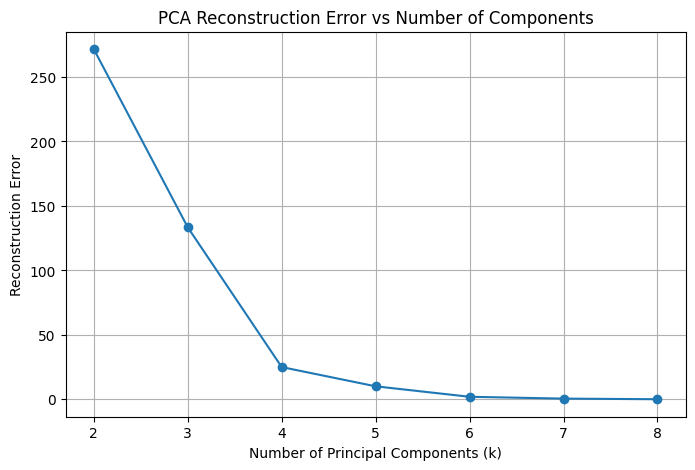

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(ks, errors, marker='o')
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Reconstruction Error")
plt.title("PCA Reconstruction Error vs Number of Components")
plt.grid(True)
plt.show()

# DBSCAN ALGORITHM


- eps → neighborhood radius

- minPts → minimum neighbors to form a dense region

In [13]:
class DBSCANScratch:
    def __init__(self, eps=0.5, min_pts=5):
        self.eps = eps
        self.min_pts = min_pts
        self.labels = None
        self.cluster_id = 0

    def _get_neighbors(self, X, point_idx):
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        #norm per row-> axis =1
        return np.where(distances <= self.eps)[0]

    def _expand_cluster(self, X, point_idx, neighbors):
        self.labels[point_idx] = self.cluster_id
        
        i = 0
        #neighbors can grow dynamically
        while i < len(neighbors):
            neighbor_idx = neighbors[i]
            

            if self.labels[neighbor_idx] == -1:
                self.labels[neighbor_idx] = self.cluster_id
            

            elif self.labels[neighbor_idx] == 0:
                self.labels[neighbor_idx] = self.cluster_id

                new_neighbors = self._get_neighbors(X, neighbor_idx)
                
                if len(new_neighbors) >= self.min_pts:
                   neighbors = np.concatenate((neighbors, new_neighbors))
            
            i += 1

    def fit(self, X):
        n_samples = X.shape[0]
        self.labels = np.zeros(n_samples)# initialize all points -> 0 → unvisited
        self.cluster_id = 0
        
        for i in range(n_samples):
            if self.labels[i] != 0:
                continue
            
            neighbors = self._get_neighbors(X, i)
            
            if len(neighbors) < self.min_pts:
                self.labels[i] = -1
            else:
                self.cluster_id += 1
                self._expand_cluster(X, i, neighbors)
        
        return self.labels


# Built-in DBSCAN -> find best eps

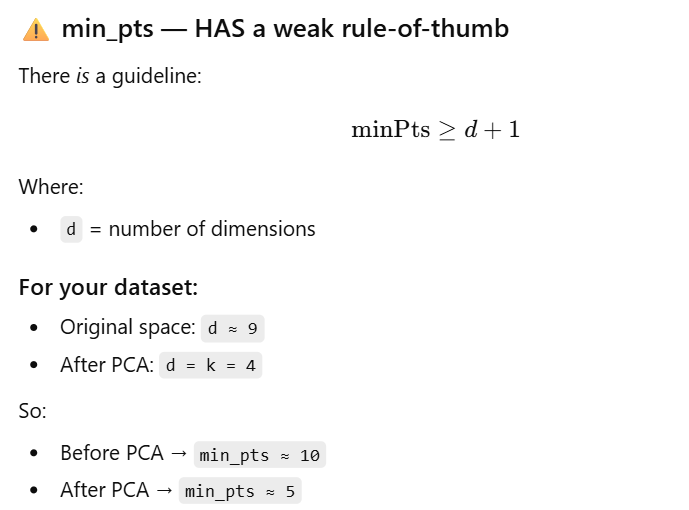


--- DBSCAN EPSILON OPTIMIZATION RESULTS ---
Optimal EPSILON found: 1.3448 (Silhouette Score: 0.2111)


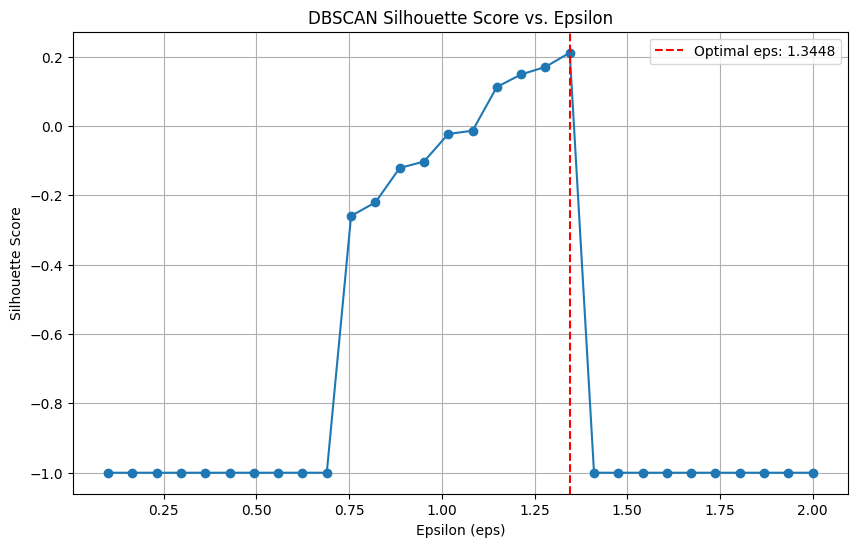

In [14]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv")
X_raw = df.drop("country", axis=1).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)



eps_range = np.linspace(0.1, 2.0, num=30) 
min_samples = 5

best_score = -1
best_eps = -1
results = []

for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled) 
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters > 1 and len(set(labels)) < len(X_scaled):
        score = silhouette_score(X_scaled, labels)
        
        if score > best_score:
            best_score = score
            best_eps = eps
            
        results.append({
            'eps': eps, 
            'score': score, 
            'n_clusters': n_clusters
        })
    else:
        results.append({
            'eps': eps, 
            'score': -1, 
            'n_clusters': n_clusters
        })


results_df = pd.DataFrame(results)

print("\n--- DBSCAN EPSILON OPTIMIZATION RESULTS ---")
print(f"Optimal EPSILON found: {best_eps:.4f} (Silhouette Score: {best_score:.4f})")

# Plotting the scores
plt.figure(figsize=(10, 6))
plt.plot(results_df['eps'], results_df['score'], marker='o', linestyle='-')
plt.title('DBSCAN Silhouette Score vs. Epsilon')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.axvline(x=best_eps, color='r', linestyle='--', label=f'Optimal eps: {best_eps:.4f}')
plt.legend()
plt.show()

# Apply DBSCAN From Scratch 

In [15]:
model = DBSCANScratch(eps=best_eps, min_pts=10)
labels = model.fit(X_scaled)

print(f"Clusters found: {len(np.unique(labels)) - (1 if -1 in labels else 0)}")
print(f"Noise points: {np.sum(labels == -1)}")


Clusters found: 3
Noise points: 57


In [16]:
df 

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [17]:
df['cluster'] = labels

cluster_analysis = df.drop('country', axis=1).groupby('cluster').mean()

pd.DataFrame(cluster_analysis.sort_values('gdpp', ascending=False))


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
3.0,4.152941,33.488235,10.067059,32.782353,36858.823529,1.394588,81.029412,1.797059,40611.764706
-1.0,55.996491,48.589807,6.735088,52.908174,21777.456140,12.623491,67.298246,3.549825,15875.298246
1.0,20.177632,40.933947,6.359737,47.800000,12684.473684,5.760842,73.393421,2.203421,7326.657895
2.0,93.835294,24.429412,5.872941,36.752941,1836.941176,6.970294,58.317647,5.409412,758.588235


In [18]:

print("\nSample Noise Countries:")
print(df[df['cluster'] == -1]['country'].values[:12]) #it holds the extremes only


Sample Noise Countries:
['Angola' 'Argentina' 'Bahrain' 'Belarus' 'Belgium' 'Botswana' 'Brunei'
 'Burundi' 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.']


In [19]:
Z_vis, _, eigvals, Q_vis = pca(X_scaled, k=2)

print(f"Explained Variance (2 PCs): {np.sum(eigvals[:2]) / np.sum(eigvals):.2%}")


Explained Variance (2 PCs): 63.13%


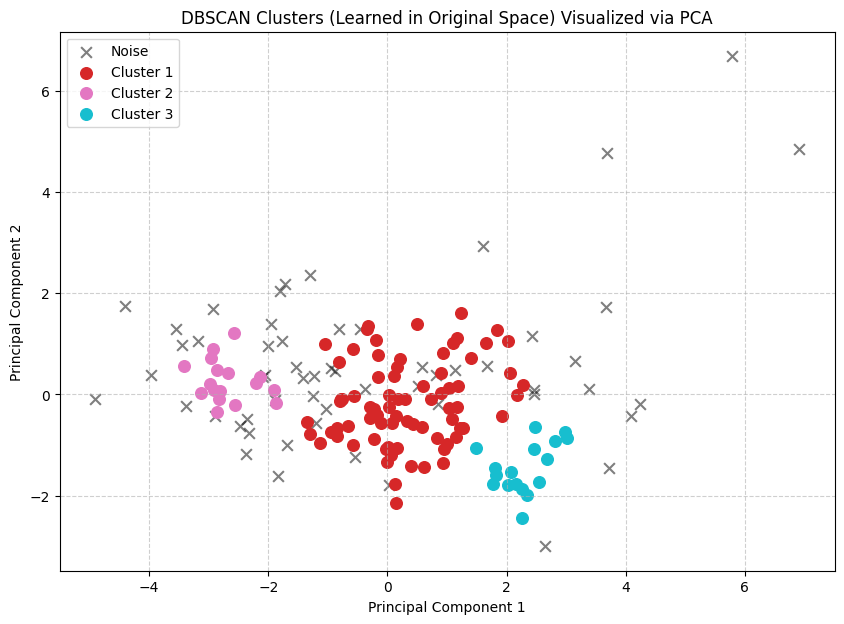

In [20]:
plt.figure(figsize=(10, 7))

unique_labels = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for lab, color in zip(unique_labels, colors):

    if lab == -1:
        plt.scatter(
            Z_vis[labels == lab, 0],
            Z_vis[labels == lab, 1],
            c='k', marker='x', s=60, alpha=0.5, label='Noise'
        )
    else:
        plt.scatter(
            Z_vis[labels == lab, 0],
            Z_vis[labels == lab, 1],
            c=[color], s=70, label=f'Cluster {int(lab)}'
        )

plt.title("DBSCAN Clusters (Learned in Original Space) Visualized via PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# DBSCAN after PCA 


In [21]:
Z_best, _, eigvals, Q_best = pca(X_scaled, k=2)

In [22]:
for eps in [0.3,0.35,0.4,0.45,0.5,0.55, 0.6]:
    model_pca = DBSCANScratch(eps=eps, min_pts=3)
    labels_pca = model_pca.fit(Z_best)
    n_clusters = len(np.unique(labels_pca)) - (1 if -1 in labels_pca else 0)
    n_noise = np.sum(labels_pca == -1)
    print(f"eps={eps}: clusters={n_clusters}, noise={n_noise}")


eps=0.3: clusters=18, noise=56
eps=0.35: clusters=10, noise=42
eps=0.4: clusters=8, noise=29
eps=0.45: clusters=6, noise=24
eps=0.5: clusters=5, noise=17
eps=0.55: clusters=3, noise=17
eps=0.6: clusters=2, noise=16


In [23]:
model_pca = DBSCANScratch(eps=0.5, min_pts=3)
labels_pca = model_pca.fit(Z_best)

print(f"Clusters after PCA: {len(np.unique(labels_pca)) - (1 if -1 in labels_pca else 0)}")
print(f"Noise points after PCA: {np.sum(labels_pca == -1)}")


Clusters after PCA: 5
Noise points after PCA: 17


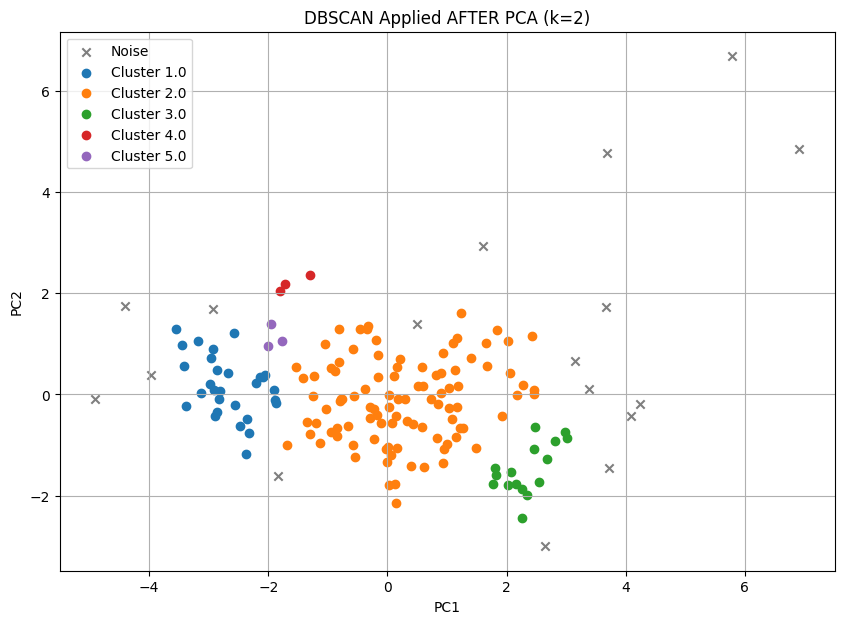

In [24]:
plt.figure(figsize=(10, 7))

for label in np.unique(labels_pca):
    if label == -1:
        plt.scatter(
            Z_best[labels_pca == label, 0],
            Z_best[labels_pca == label, 1],
            c='k', marker='x', label='Noise', alpha=0.5
        )
    else:
        plt.scatter(
            Z_best[labels_pca == label, 0],
            Z_best[labels_pca == label, 1],
            label=f'Cluster {label}'
        )

plt.title("DBSCAN Applied AFTER PCA (k=2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
model = DBSCANScratch(eps=best_eps, min_pts=10)
labels_before = model.fit(X_scaled)

print(f"Clusters (before PCA): {len(np.unique(labels_before)) - (1 if -1 in labels_before else 0)}")
print(f"Noise points: {np.sum(labels_before == -1)}")


Clusters (before PCA): 3
Noise points: 57


In [26]:
Z_vis, _, eigvals, _ = pca(X_scaled, k=2)

print(f"Explained variance (2 PCs): {np.sum(eigvals[:2]) / np.sum(eigvals):.2%}")


Explained variance (2 PCs): 63.13%


In [27]:
model_pca = DBSCANScratch(eps=0.5, min_pts=3)
labels_after = model_pca.fit(Z_vis)

print(f"Clusters (after PCA): {len(np.unique(labels_after)) - (1 if -1 in labels_after else 0)}")
print(f"Noise points: {np.sum(labels_after == -1)}")


Clusters (after PCA): 5
Noise points: 17


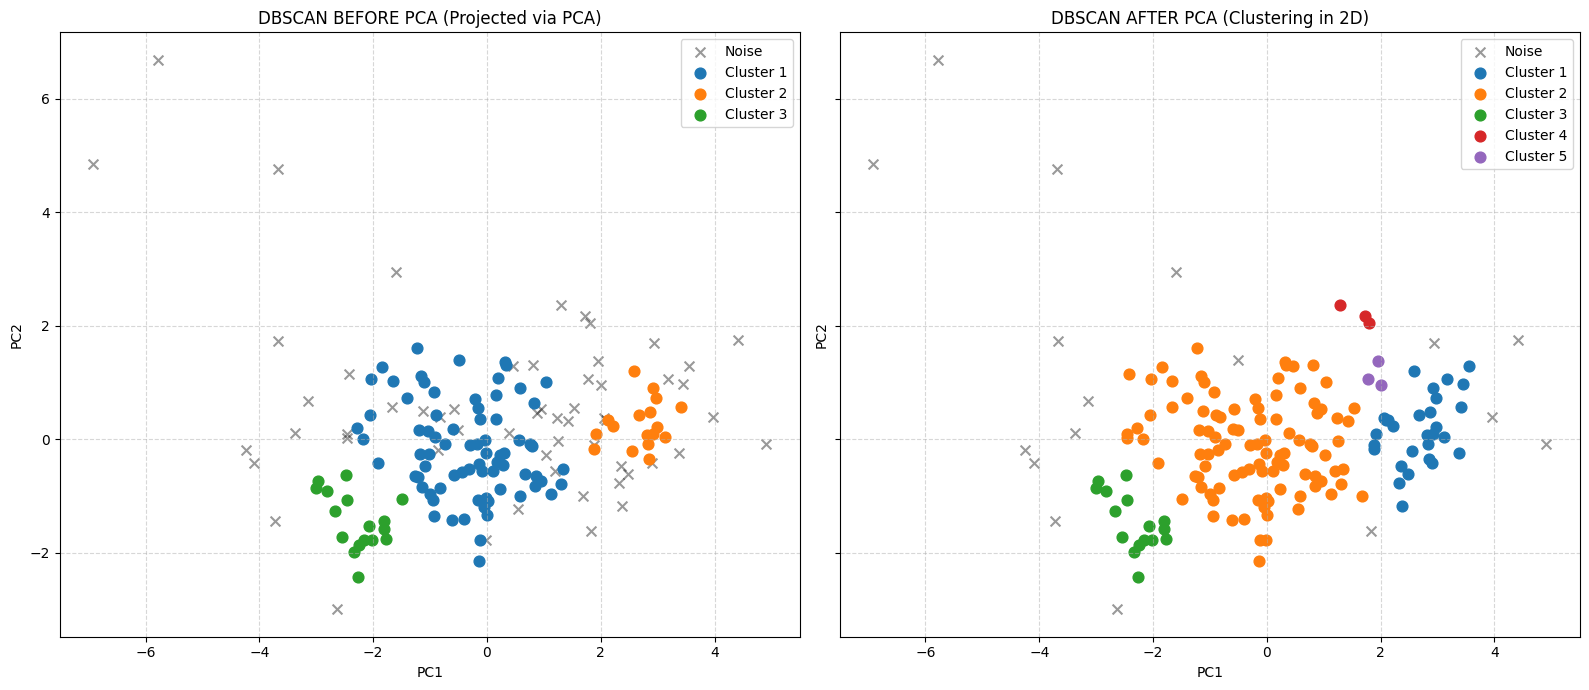

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

titles = [
    "DBSCAN BEFORE PCA (Projected via PCA)",
    "DBSCAN AFTER PCA (Clustering in 2D)"
]

label_sets = [labels_before, labels_after]

for ax, labels_set, title in zip(axes, label_sets, titles):
    for lab in np.unique(labels_set):
        if lab == -1:
            ax.scatter(
                Z_vis[labels_set == lab, 0],
                Z_vis[labels_set == lab, 1],
                c='k', marker='x', s=50, alpha=0.4, label='Noise'
            )
        else:
            ax.scatter(
                Z_vis[labels_set == lab, 0],
                Z_vis[labels_set == lab, 1],
                s=60, label=f'Cluster {int(lab)}'
            )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()


#### Sillouette 
- a = average distance to points in same cluster
- b = average distance to points in nearest other cluster

- silhouette = (b - a) / max(a, b)


| Score   | Meaning               |
| ------- | --------------------- |
| **+1**  | Very good clustering  |
| **0**   | Overlapping clusters  |
| **< 0** | Probably misclustered |


In [29]:
from sklearn.metrics import silhouette_score

if len(set(labels_before)) > 1:
    print("Silhouette BEFORE PCA:",
          silhouette_score(X_scaled, labels_before))

if len(set(labels_after)) > 1:
    print("Silhouette AFTER PCA:",
          silhouette_score(Z_vis, labels_after))


Silhouette BEFORE PCA: 0.1227859632499463
Silhouette AFTER PCA: 0.16680936625115997
